In [1]:
import pandas as pd
import os
import numpy as np
from datetime import datetime

# Configurações para melhor visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Listar arquivos na pasta data (CSVs)
data_folder = "data"
files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

# Dicionário para armazenar DataFrames
tables = {}

print("Carregando tabelas...")
for file in files:
    table_name = file.split('.')[0]
    df = pd.read_csv(os.path.join(data_folder, file))
    tables[table_name] = df
    print(f"✓ {table_name}: {df.shape[0]} linhas, {df.shape[1]} colunas")

print(f"\nTabelas disponíveis: {list(tables.keys())}")

Carregando tabelas...
✓ dashboard_data_core: 73929 linhas, 26 colunas
✓ dashboard_data: 73929 linhas, 42 colunas
✓ dashboard_data_semantic: 73929 linhas, 49 colunas
✓ medicamentos: 22 linhas, 21 colunas
✓ prescricaomedicamento: 73929 linhas, 15 colunas
✓ medicos: 45025 linhas, 8 colunas

Tabelas disponíveis: ['dashboard_data_core', 'dashboard_data', 'dashboard_data_semantic', 'medicamentos', 'prescricaomedicamento', 'medicos']


# 📊 Explorador de Dados - Dashboard Saúde

Este notebook explora os datasets do sistema de prescrição médica, dividindo a análise em seções específicas para cada tabela e uma camada semântica final.

# 💊 Seção 1: Análise da Tabela Medicamentos

Exploração detalhada da tabela de medicamentos, incluindo tipos, classes terapêuticas e características especiais.

In [4]:
if 'medicamentos' in tables:
    med = tables['medicamentos'].copy()

    print("=== MEDICAMENTOS - ANÁLISE GERAL ===")
    print(f"Total de medicamentos: {len(med)}")
    print(f"Colunas: {list(med.columns)}")
    print()

    # Informações básicas
    print("📋 Informações básicas:")
    print(med.info())
    print()

    # Amostra dos dados
    print("🔍 Amostra dos dados:")
    print(med.head(10))
    print()

    # Análise de valores nulos
    print("❓ Valores nulos por coluna:")
    null_counts = med.isnull().sum()
    null_percentages = (null_counts / len(med) * 100).round(2)
    null_analysis = pd.DataFrame({
        'Nulos': null_counts,
        'Percentual': null_percentages
    })
    print(null_analysis[null_analysis['Nulos'] > 0])
    print()

    # Análise das classes especiais
    print("🏥 Classes especiais de medicamentos:")
    special_classes = ['antimicrobiano', 'controleespecial', 'mip']
    for col in special_classes:
        if col in med.columns:
            counts = med[col].value_counts(dropna=False)
            pct = (counts / len(med) * 100).round(2)
            print(f"\n{col.upper()}:")
            for val, count in counts.items():
                print(f"  {val}: {count} ({pct[val]}%)")

    # Top medicamentos por frequência (se houver coluna de contagem)
    if 'nome' in med.columns:
        print(f"\n💊 Top 10 medicamentos mais comuns:")
        top_meds = med['nome'].value_counts().head(10)
        for med_name, count in top_meds.items():
            print(f"  {med_name}: {count} ocorrências")

    # Estatísticas descritivas para colunas numéricas
    numeric_cols = med.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"\n📊 Estatísticas das colunas numéricas:")
        print(med[numeric_cols].describe())

else:
    print("❌ Tabela 'medicamentos' não encontrada!")

=== MEDICAMENTOS - ANÁLISE GERAL ===
Total de medicamentos: 22
Colunas: ['idmedicamento', 'nome', 'concentracao', 'unidade', 'codigoatc', 'mip', 'portaria344', 'idviaadministracao', 'bula', 'antimicrobiano', 'controleespecial', 'idformafarmaceutica', 'idtipomedicamento', 'catmat', 'idmedicamentoantimicrobiano', 'idportaria344', 'impressaoduasvias', 'idcodigoatc', 'idvmp', 'idcategoriacomercial', 'codigosigtap']

📋 Informações básicas:
<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idmedicamento                22 non-null     int64  
 1   nome                         22 non-null     str    
 2   concentracao                 22 non-null     str    
 3   unidade                      22 non-null     str    
 4   codigoatc                    22 non-null     str    
 5   mip                          22 non-null     bool   
 6   

In [ ]:
display(med)

,idmedicamento,nome,concentracao,unidade,codigoatc,mip,portaria344,idviaadministracao,bula,antimicrobiano,controleespecial,idformafarmaceutica,idtipomedicamento,catmat,idmedicamentoantimicrobiano,idportaria344,impressaoduasvias,idcodigoatc,idvmp,idcategoriacomercial,codigosigtap
0,8156,Cloridrato de Clindamicina,300,mg,J01FF01,False,NaN,1,NaN,True,True,15,3,BR0268436U0041,1,0,1,3325.0,1617,74,NaN
1,9366,Codein,30,mg,R05DA04,False,LISTA - A2,1,-,False,False,26,1,NaN,3,13,1,4867.0,2756,4,604050038.0
2,20254,Novamox,400 + 57,mg/5mL + mg/5mL,J01CR02,False,NaN,1,-,True,True,420,22,NaN,1,0,1,2611.0,5319,74,NaN
3,42541,Cloridrato de Fluoxetina,20,mg,N06AB03,False,NaN,1,NaN,False,True,37,3,NaN,3,6,1,NaN,1865,32,NaN
4,14714,Glifage XR,500,mg,A10BA02,False,NaN,1,NaN,False,False,401,1,NaN,3,0,0,780.0,1736,14,NaN
5,11341,Donaren Retard,150,mg,A10BD11,False,LISTA - C1,1,NaN,False,False,32,6,NaN,3,6,1,4455.0,7543,32,NaN
6,41452,Sulfato de Salbutamol,100,mcg/Dose,R03CC02,False,NaN,12,NaN,False,False,174,3,BR0294887U0084,3,0,0,4748.0,4352,8,NaN
7,1124,Acetilcisteína,600,mg,R05CB01,True,NaN,1,NaN,False,False,88,3,NaN,3,0,0,4850.0,295,4,NaN
8,5783,Carbonato de Lítio,300,mg,N05AN01,False,LISTA - C1,1,NaN,False,True,26,3,BR0267621U0042,3,6,1,4305.0,1172,29,NaN
9,13501,Fluconazol,150,mg,J02AC01,False,NaN,1,NaN,False,False,15,3,BR0267662U0041,3,0,0,3399.0,2713,72,NaN


📊 DISTRIBUIÇÃO POR CLASSES DE MEDICAMENTO:


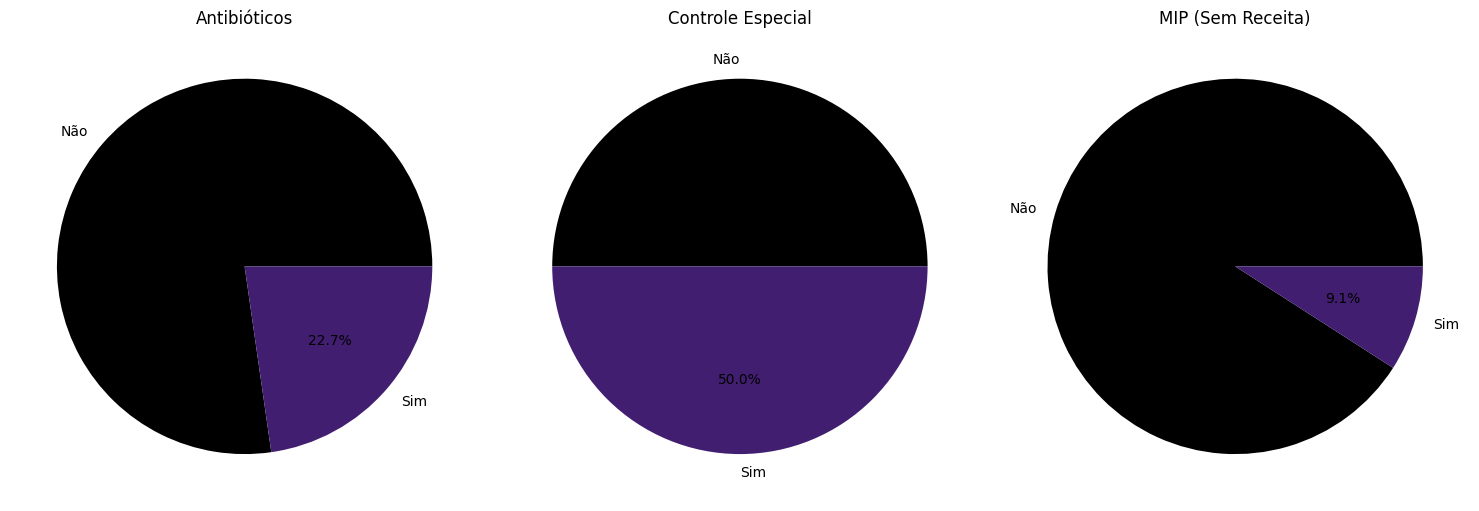


🏆 TOP MEDICAMENTOS (simulação baseada na distribuição):
nome
Cloridrato de Clindamicina    1
Codein                        1
Novamox                       1
Cloridrato de Fluoxetina      1
Glifage XR                    1
Donaren Retard                1
Sulfato de Salbutamol         1
Acetilcisteína                1
Carbonato de Lítio            1
Fluconazol                    1
Name: count, dtype: int64


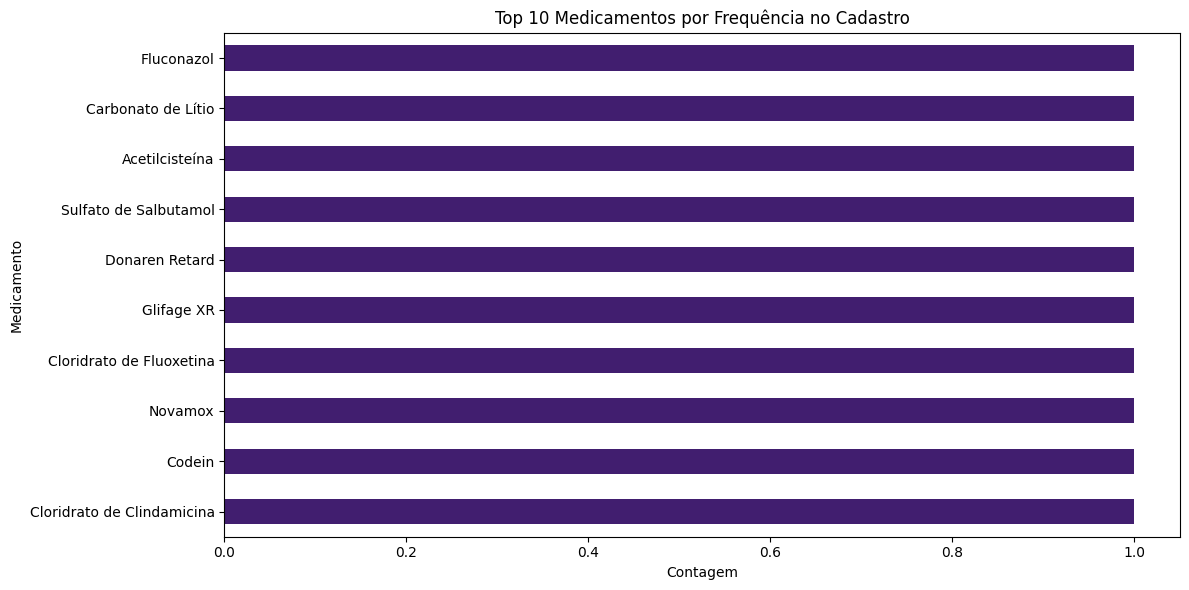


🔗 MATRIZ DE CORRELAÇÃO ENTRE CLASSES:
                  antimicrobiano  controleespecial           mip
antimicrobiano          1.000000      5.423261e-01 -1.714986e-01
controleespecial        0.542326      1.000000e+00 -2.194271e-18
mip                    -0.171499     -2.194271e-18  1.000000e+00


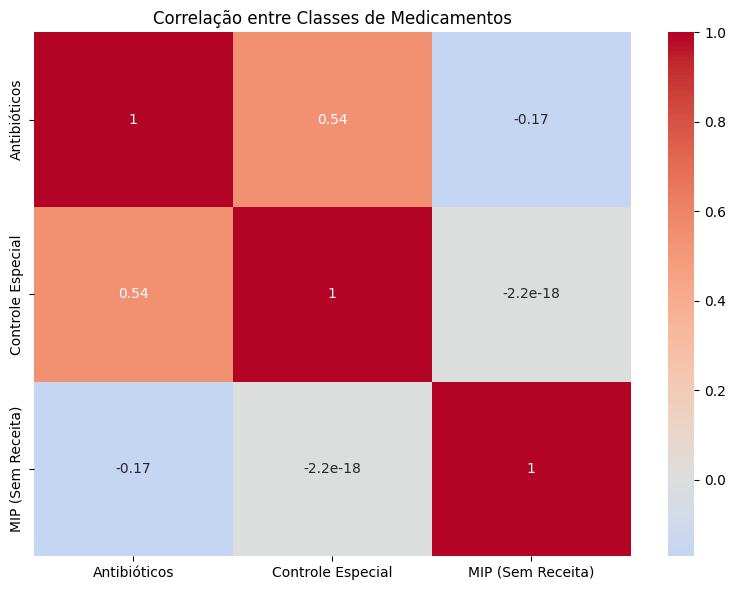


📈 ESTATÍSTICAS DESCRITIVAS COMPLETAS:
       idmedicamento  idviaadministracao  idformafarmaceutica  \
count      22.000000           22.000000            22.000000   
mean    16199.727273            3.045455           109.772727   
std     14259.890370            3.823203           115.510845   
min      1124.000000            1.000000            15.000000   
25%      6184.000000            1.000000            37.000000   
50%     10511.500000            1.000000            41.000000   
75%     25877.500000            2.500000           174.000000   
max     42541.000000           12.000000           420.000000   

       idtipomedicamento  idmedicamentoantimicrobiano  idportaria344  \
count          22.000000                    22.000000      22.000000   
mean            3.636364                     2.545455       2.500000   
std             4.392043                     0.857864       3.674235   
min             1.000000                     1.000000       0.000000   
25%            

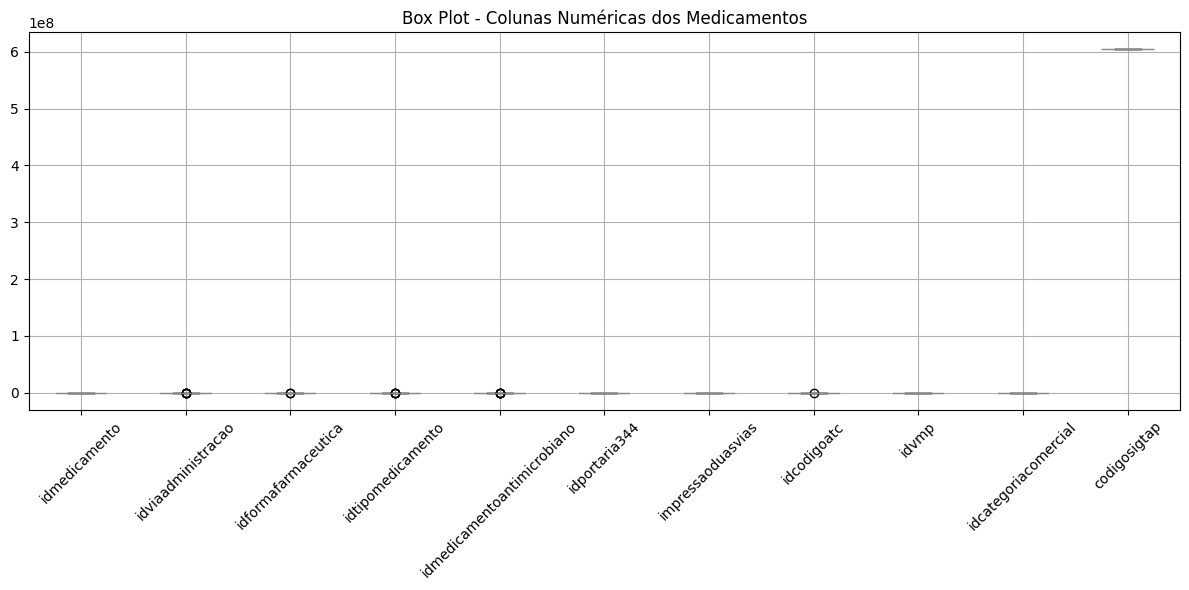

In [3]:
# Análise Exploratória Detalhada - Medicamentos
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# Recarregar dados (devido ao restart do kernel)
data_folder = "data"
files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
tables = {}
for file in files:
    table_name = file.split('.')[0]
    df = pd.read_csv(os.path.join(data_folder, file))
    tables[table_name] = df

# Configurar estilo dos gráficos
plt.style.use('default')
sns.set_palette("husl")

# Carregar tabela de medicamentos
if 'medicamentos' in tables:
    med = tables['medicamentos'].copy()

    print("📊 DISTRIBUIÇÃO POR CLASSES DE MEDICAMENTO:")

    med_classes = ['antimicrobiano', 'controleespecial', 'mip']
    class_names = ['Antibióticos', 'Controle Especial', 'MIP (Sem Receita)']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, (col, name) in enumerate(zip(med_classes, class_names)):
        if col in med.columns:
            counts = med[col].value_counts()
            axes[i].pie(counts.values, labels=['Não', 'Sim'], autopct='%1.1f%%',
                       colors=['#000000', '#411e6f'])
            axes[i].set_title(f'{name}')

    plt.tight_layout()
    plt.show()

    # 2. Top medicamentos mais comuns
    print("\n🏆 TOP MEDICAMENTOS (simulação baseada na distribuição):")
    if 'nome' in med.columns:
        # Como não temos contagem real, vamos mostrar distribuição por nome
        med_dist = med['nome'].value_counts().head(10)
        print(med_dist)

        # Gráfico de barras
        plt.figure(figsize=(12, 6))
        med_dist.plot(kind='barh', color='#411e6f')
        plt.title('Top 10 Medicamentos por Frequência no Cadastro')
        plt.xlabel('Contagem')
        plt.ylabel('Medicamento')
        plt.tight_layout()
        plt.show()

    # 3. Análise de correlação entre classes
    print("\n🔗 MATRIZ DE CORRELAÇÃO ENTRE CLASSES:")
    correlation_matrix = med[med_classes].corr()
    print(correlation_matrix)

    # Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Correlação entre Classes de Medicamentos')
    plt.tight_layout()
    plt.show()

    # 4. Estatísticas descritivas completas
    print("\n📈 ESTATÍSTICAS DESCRITIVAS COMPLETAS:")
    numeric_cols = med.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        desc_stats = med[numeric_cols].describe()
        print(desc_stats)

        # Box plots para colunas numéricas
        if len(numeric_cols) > 1:
            plt.figure(figsize=(12, 6))
            med[numeric_cols].boxplot()
            plt.title('Box Plot - Colunas Numéricas dos Medicamentos')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

else:
    print("❌ Tabela 'medicamentos' não encontrada!")

print("\n" + "="*80)

# 👨‍⚕️ Seção 2: Análise da Tabela Médicos

Exploração detalhada da tabela de médicos, incluindo especialidades, demografia e padrões de prescrição.

In [5]:
if 'medicos' in tables:
    docs = tables['medicos'].copy()

    print("=== MÉDICOS - ANÁLISE GERAL ===")
    print(f"Total de médicos: {len(docs)}")
    print(f"Colunas: {list(docs.columns)}")
    print()

    # Informações básicas
    print("📋 Informações básicas:")
    print(docs.info())
    print()

    # Amostra dos dados
    print("🔍 Amostra dos dados:")
    print(docs.head(10))
    print()

    # Análise de valores nulos
    print("❓ Valores nulos por coluna:")
    null_counts = docs.isnull().sum()
    null_percentages = (null_counts / len(docs) * 100).round(2)
    null_analysis = pd.DataFrame({
        'Nulos': null_counts,
        'Percentual': null_percentages
    })
    print(null_analysis[null_analysis['Nulos'] > 0])
    print()

    # Distribuição por especialidade
    if 'especialidade' in docs.columns:
        print("🏥 Distribuição por especialidade:")
        esp_counts = docs['especialidade'].value_counts().head(15)
        esp_pct = (esp_counts / len(docs) * 100).round(2)
        for esp, count in esp_counts.items():
            print(f"  {esp}: {count} médicos ({esp_pct[esp]}%)")
        print()

    # Análise demográfica - Gênero
    if 'genero' in docs.columns:
        print("👥 Distribuição por gênero:")
        gender_counts = docs['genero'].value_counts(dropna=False)
        gender_pct = (gender_counts / len(docs) * 100).round(2)
        for gender, count in gender_counts.items():
            gender_label = str(gender) if pd.notna(gender) else "Não informado"
            print(f"  {gender_label}: {count} médicos ({gender_pct[gender]}%)")
        print()

    # Análise demográfica - Idade
    if 'idade' in docs.columns:
        print("🎂 Estatísticas de idade:")
        age_stats = docs['idade'].describe()
        print(age_stats)
        print()

        # Distribuição por faixa etária
        age_bins = [0, 30, 40, 50, 60, 70, 100]
        age_labels = ['<30', '30-39', '40-49', '50-59', '60-69', '70+']
        docs['faixa_etaria'] = pd.cut(docs['idade'], bins=age_bins, labels=age_labels, right=False)

        print("📅 Distribuição por faixa etária:")
        age_dist = docs['faixa_etaria'].value_counts().sort_index()
        age_dist_pct = (age_dist / len(docs) * 100).round(2)
        for faixa, count in age_dist.items():
            print(f"  {faixa}: {count} médicos ({age_dist_pct[faixa]}%)")
        print()

    # Análise por estado
    if 'estado' in docs.columns:
        print("📍 Top 10 estados com mais médicos:")
        state_counts = docs['estado'].value_counts().head(10)
        state_pct = (state_counts / len(docs) * 100).round(2)
        for state, count in state_counts.items():
            print(f"  {state}: {count} médicos ({state_pct[state]}%)")

else:
    print("❌ Tabela 'medicos' não encontrada!")

=== MÉDICOS - ANÁLISE GERAL ===
Total de médicos: 45025
Colunas: ['idmedico', 'conselhoprofissional', 'ufconselho', 'genero', 'idade', 'cidade', 'estado', 'especialidade']

📋 Informações básicas:
<class 'pandas.DataFrame'>
RangeIndex: 45025 entries, 0 to 45024
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idmedico              45025 non-null  int64  
 1   conselhoprofissional  45025 non-null  str    
 2   ufconselho            45025 non-null  str    
 3   genero                38980 non-null  str    
 4   idade                 29 non-null     float64
 5   cidade                19106 non-null  str    
 6   estado                21042 non-null  str    
 7   especialidade         44996 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 4.0 MB
None

🔍 Amostra dos dados:
   idmedico conselhoprofissional ufconselho genero  idade          cidade  \
0    140479                  CRM   

In [15]:
display(docs)

,idmedico,conselhoprofissional,ufconselho,genero,idade,cidade,estado,especialidade
0,140479,CRM,MG,F,NaN,MANHUACU,MG,ORTOPEDIA E TRAUMATOLOGIA
1,140966,CRO,SP,M,NaN,SAO PAULO,SP,SEM ESPECIALIDADE
2,141156,CRO,MG,F,NaN,BELO HORIZONTE,MG,CLINICA MEDICA
3,141255,CRM,ES,M,NaN,VITORIA,ES,RADIOLOGIA E DIAGNOSTICO POR IMAGEM
4,141315,CRM,GO,F,NaN,GOIANIA,GO,PEDIATRIA
...,...,...,...,...,...,...,...,...
45020,139917,CRM,SP,F,NaN,CAMPINAS,SP,PSIQUIATRIA
45021,140003,CRO,SP,M,NaN,TABOAO DA SERRA,SP,SEM ESPECIALIDADE
45022,140055,CRO,SP,M,NaN,SAO PAULO,SP,SEM ESPECIALIDADE
45023,140115,CRO,SP,F,NaN,ATIBAIA,SP,PEDIATRIA



📋 ANÁLISE DE CONSELHO PROFISSIONAL:
Distribuição por Conselho Profissional:

  CRM - Conselho Regional de Medicina       41722 médicos ( 92.7%)
  CRO - Conselho Regional de Odontologia     2895 médicos (  6.4%)
  Não informado                               408 médicos (  0.9%)



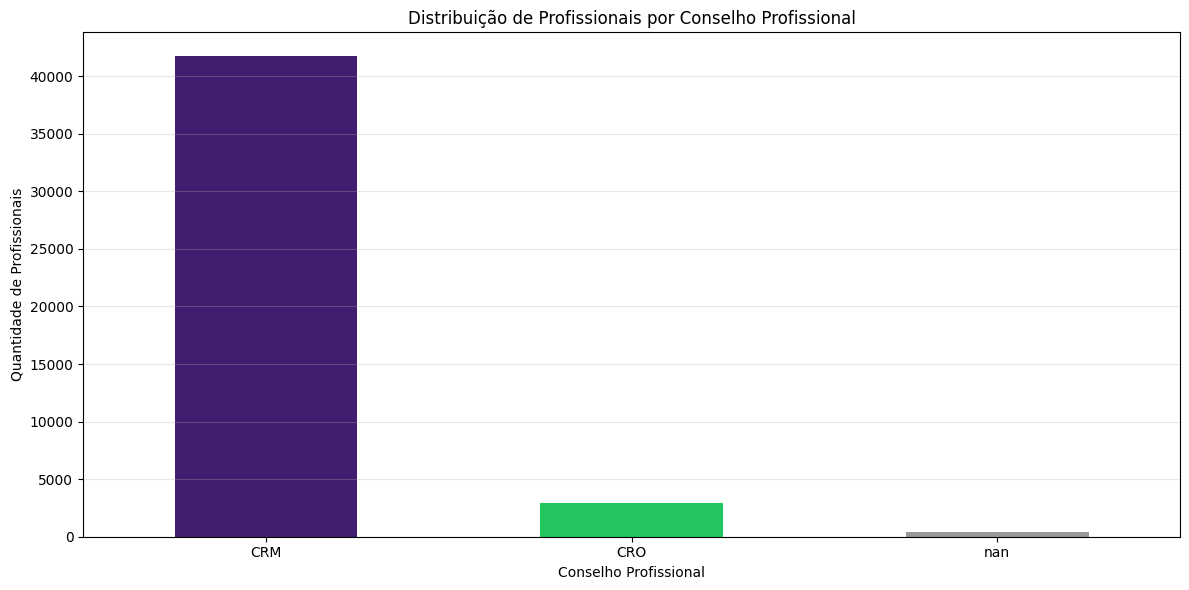

📍 Distribuição por Estado e Conselho:

CRM (Médicos):
  SP:   8280 ( 19.8%)
  ES:   1730 (  4.1%)
  RS:   1486 (  3.6%)
  MG:   1215 (  2.9%)
  PR:   1105 (  2.6%)

CRO (Odontólogos):
  SP:   1167 ( 40.3%)
  MG:    295 ( 10.2%)
  RJ:    132 (  4.6%)
  AM:    124 (  4.3%)
  PR:    105 (  3.6%)



In [25]:
# 5. Análise de Conselho Profissional (CRO vs CRM)
print("\n📋 ANÁLISE DE CONSELHO PROFISSIONAL:")
if 'conselhoprofissional' in docs.columns:
    # Extrair o tipo de conselho (CRM, CRO, etc)
    docs['tipo_conselho'] = docs['conselhoprofissional'].str.extract(r'(CRM|CRO|CRMV|etc)', expand=False)
    
    # Distribuição por tipo de conselho
    conselho_counts = docs['tipo_conselho'].value_counts(dropna=False)
    conselho_pct = (conselho_counts / len(docs) * 100).round(2)
    
    print("Distribuição por Conselho Profissional:")
    print()
    for conselho, count in conselho_counts.items():
        conselho_name = conselho if pd.notna(conselho) else "Não informado"
        conselho_label = {
            'CRM': 'CRM - Conselho Regional de Medicina',
            'CRO': 'CRO - Conselho Regional de Odontologia',
            'CRMV': 'CRMV - Conselho Regional de Medicina Veterinária'
        }.get(conselho_name, conselho_name)
        print(f"  {conselho_label:<40} {count:>6} médicos ({conselho_pct[conselho]:>5.1f}%)")
    print()
    
    # Gráfico de distribuição por conselho
    plt.figure(figsize=(12, 6))
    
    # Preparar dados para gráfico
    conselho_plot = conselho_counts.dropna()
    if len(conselho_plot) > 0:
        colors_conselho = {'CRM': '#411e6f', 'CRO': '#22c55e', 'CRMV': '#f59e0b'}
        bar_colors = [colors_conselho.get(c, '#999999') for c in conselho_plot.index]
        
        conselho_plot.plot(kind='bar', color=bar_colors, figsize=(12, 6))
        plt.title('Distribuição de Profissionais por Conselho Profissional')
        plt.xlabel('Conselho Profissional')
        plt.ylabel('Quantidade de Profissionais')
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # Análise geográfica por conselho
    if 'estado' in docs.columns and 'tipo_conselho' in docs.columns:
        print("📍 Distribuição por Estado e Conselho:")
        print()
        
        for conselho_type in conselho_counts[conselho_counts.index.notna()].index:
            conselho_data = docs[docs['tipo_conselho'] == conselho_type]
            estado_dist = conselho_data['estado'].value_counts().head(5)
            
            conselho_label = {
                'CRM': 'CRM (Médicos)',
                'CRO': 'CRO (Odontólogos)',
                'CRMV': 'CRMV (Veterinários)'
            }.get(conselho_type, conselho_type)
            
            print(f"{conselho_label}:")
            for estado, count in estado_dist.items():
                pct = round(count / len(conselho_data) * 100, 1)
                print(f"  {estado}: {count:>6} ({pct:>5.1f}%)")
            print()

else:
    print("❌ Coluna 'conselhoprofissional' não encontrada!")

print("="*80)

# 📝 Seção 3: Análise da Tabela Prescrição Medicamento

Exploração detalhada da tabela de prescrições, incluindo padrões temporais, conversões e canais de venda.

In [6]:
if 'prescricaomedicamento' in tables:
    presc = tables['prescricaomedicamento'].copy()

    print("=== PRESCRIÇÃO MEDICAMENTO - ANÁLISE GERAL ===")
    print(f"Total de prescrições: {len(presc)}")
    print(f"Colunas: {list(presc.columns)}")
    print()

    # Informações básicas
    print("📋 Informações básicas:")
    print(presc.info())
    print()

    # Amostra dos dados
    print("🔍 Amostra dos dados:")
    print(presc.head(10))
    print()

    # Converter datas se existirem
    date_cols = ['dataprescricao', 'datavenda']
    for col in date_cols:
        if col in presc.columns:
            try:
                presc[col] = pd.to_datetime(presc[col])
                print(f"✓ Coluna {col} convertida para datetime")
            except:
                print(f"⚠️ Não foi possível converter {col} para datetime")

    # Análise temporal básica
    if 'dataprescricao' in presc.columns and pd.api.types.is_datetime64_any_dtype(presc['dataprescricao']):
        print("📅 Período das prescrições:")
        print(f"  Data inicial: {presc['dataprescricao'].min()}")
        print(f"  Data final: {presc['dataprescricao'].max()}")
        print(f"  Dias de cobertura: {(presc['dataprescricao'].max() - presc['dataprescricao'].min()).days}")
        print()

        # Prescrições por dia da semana
        presc['dia_semana'] = presc['dataprescricao'].dt.day_name()
        print("📊 Prescrições por dia da semana:")
        weekday_counts = presc['dia_semana'].value_counts()
        weekday_pct = (weekday_counts / len(presc) * 100).round(2)
        for day, count in weekday_counts.items():
            print(f"  {day}: {count} ({weekday_pct[day]}%)")
        print()

        # Prescrições por hora do dia
        presc['hora'] = presc['dataprescricao'].dt.hour
        print("🕐 Prescrições por hora do dia:")
        hour_counts = presc['hora'].value_counts().sort_index()
        hour_pct = (hour_counts / len(presc) * 100).round(2)
        for hour, count in hour_counts.items():
            print(f"  {hour:02d}h: {count} ({hour_pct[hour]}%)")
        print()

    # Análise de conversão
    print("🎯 Análise de conversão:")
    if 'visualizadapaciente' in presc.columns:
        viewed = presc['visualizadapaciente'].sum()
        total = len(presc)
        open_rate = (viewed / total * 100).round(2)
        print(f"  Open Rate: {viewed}/{total} ({open_rate}%)")

    if 'itemvendido' in presc.columns:
        sold = presc['itemvendido'].sum()
        conv_rate = (sold / viewed * 100).round(2) if viewed > 0 else 0
        print(f"  Conversão: {sold}/{viewed} ({conv_rate}%)")
    print()

    # Canais de venda
    if 'canalvenda' in presc.columns:
        print("🛒 Canais de venda:")
        channel_counts = presc['canalvenda'].value_counts(dropna=False)
        channel_pct = (channel_counts / len(presc) * 100).round(2)
        for channel, count in channel_counts.items():
            channel_name = str(channel) if pd.notna(channel) else "Não informado"
            print(f"  {channel_name}: {count} ({channel_pct[channel]}%)")
        print()

    # Análise por convênio
    if 'idconvenio' in presc.columns:
        print("🏥 Tipos de convênio:")
        convenio_counts = presc['idconvenio'].value_counts(dropna=False)
        convenio_pct = (convenio_counts / len(presc) * 100).round(2)
        for conv, count in convenio_counts.head(10).items():
            conv_name = f"Convênio {conv}" if pd.notna(conv) else "Particular"
            print(f"  {conv_name}: {count} ({convenio_pct[conv]}%)")
        print()

    # Análise geográfica
    geo_cols = ['estadopaciente', 'cidadepaciente']
    for col in geo_cols:
        if col in presc.columns:
            print(f"📍 Top 10 {col.replace('paciente', '').upper()}:")
            geo_counts = presc[col].value_counts().head(10)
            geo_pct = (geo_counts / len(presc) * 100).round(2)
            for loc, count in geo_counts.items():
                print(f"  {loc}: {count} ({geo_pct[loc]}%)")
            print()

else:
    print("❌ Tabela 'prescricaomedicamento' não encontrada!")

=== PRESCRIÇÃO MEDICAMENTO - ANÁLISE GERAL ===
Total de prescrições: 73929
Colunas: ['idprescricao', 'idmedicamento', 'dataprescricao', 'idmedico', 'idpaciente', 'idconvenio', 'nascimentopaciente', 'sexopaciente', 'estadopaciente', 'cidadepaciente', 'visualizadapaciente', 'permitirimpressao', 'itemvendido', 'datavenda', 'canalvenda']

📋 Informações básicas:
<class 'pandas.DataFrame'>
RangeIndex: 73929 entries, 0 to 73928
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   idprescricao         73929 non-null  int64  
 1   idmedicamento        73929 non-null  int64  
 2   dataprescricao       73929 non-null  str    
 3   idmedico             73929 non-null  int64  
 4   idpaciente           73929 non-null  int64  
 5   idconvenio           30070 non-null  float64
 6   nascimentopaciente   72716 non-null  str    
 7   sexopaciente         73929 non-null  str    
 8   estadopaciente       65863 non-null  

In [24]:
# Análise de convênios - Distribuição e estatísticas
print("🏥 ANÁLISE DETALHADA DE CONVÊNIOS")
print("="*80)

# Estatísticas gerais de convênios
print("\n📊 Estatísticas de Convênios:")
total_prescricoes = len(presc)
com_convenio = presc['idconvenio'].notna().sum()
sem_convenio = presc['idconvenio'].isna().sum()
distinct_convenios = presc['idconvenio'].nunique()

print(f"Total de prescrições: {total_prescricoes:,}")
print(f"Com convênio: {com_convenio:,} ({com_convenio/total_prescricoes*100:.1f}%)")
print(f"Sem convênio (Particular): {sem_convenio:,} ({sem_convenio/total_prescricoes*100:.1f}%)")
print(f"Convênios distintos: {distinct_convenios}")

# Top 15 convênios
print("\n💳 Top 15 Convênios por Volume:")
top_convenios = presc['idconvenio'].value_counts().head(15)
for i, (convenio_id, count) in enumerate(top_convenios.items(), 1):
    pct = (count / total_prescricoes * 100)
    convenio_label = f"Convênio {int(convenio_id)}" if pd.notna(convenio_id) else "Particular"
    print(f"{i:2d}. {convenio_label:<20} {count:>8,} prescrições ({pct:>5.1f}%)")

# Análise de conversão por convênio
print("\n📈 Taxa de Conversão por Convênio (Top 10):")
conv_by_convenio = presc.groupby('idconvenio').agg({
    'idprescricao': 'count',
    'visualizadapaciente': 'sum',
    'itemvendido': 'sum'
}).rename(columns={
    'idprescricao': 'total',
    'visualizadapaciente': 'visualizadas',
    'itemvendido': 'vendidas'
})

conv_by_convenio['open_rate'] = conv_by_convenio['visualizadas'] / conv_by_convenio['total']
conv_by_convenio['conv_rate'] = conv_by_convenio['vendidas'] / conv_by_convenio['visualizadas']
conv_by_convenio = conv_by_convenio.sort_values('total', ascending=False).head(10)

for convenio_id, row in conv_by_convenio.iterrows():
    convenio_label = f"Convênio {int(convenio_id)}" if pd.notna(convenio_id) else "Particular"
    print(f"{convenio_label:<20} | {row['total']:>6.0f} presc | "
          f"Open: {row['open_rate']:>6.1%} | Conv: {row['conv_rate']:>6.1%}")

🏥 ANÁLISE DETALHADA DE CONVÊNIOS

📊 Estatísticas de Convênios:
Total de prescrições: 73,929
Com convênio: 30,070 (40.7%)
Sem convênio (Particular): 43,859 (59.3%)
Convênios distintos: 18349

💳 Top 15 Convênios por Volume:
 1. Convênio 981873         4,627 prescrições (  6.3%)
 2. Convênio 296156         3,487 prescrições (  4.7%)
 3. Convênio 1725637          495 prescrições (  0.7%)
 4. Convênio 1656285          377 prescrições (  0.5%)
 5. Convênio 54               366 prescrições (  0.5%)
 6. Convênio 1113267          232 prescrições (  0.3%)
 7. Convênio 474369           177 prescrições (  0.2%)
 8. Convênio 1216942          119 prescrições (  0.2%)
 9. Convênio 1710832           87 prescrições (  0.1%)
10. Convênio 1632649           46 prescrições (  0.1%)
11. Convênio 3431712           44 prescrições (  0.1%)
12. Convênio 1244942           33 prescrições (  0.0%)
13. Convênio 1632749           33 prescrições (  0.0%)
14. Convênio 1389568           31 prescrições (  0.0%)
15. Conv

👥 ANÁLISE DE IDADE DO PACIENTE

📊 ANÁLISE POR FAIXA ETÁRIA:

Faixa Etária    Prescrições  Abertas      Vendidas     Open %     Conv %    
--------------------------------------------------------------------------------
≤18             14,172       6,610        680          46.6       10.3      
19-25           7,211        4,101        367          56.9       8.9       
26-35           13,347       7,911        900          59.3       11.4      
36-45           11,975       6,659        1,047        55.6       15.7      
46-55           8,819        4,262        706          48.3       16.6      
56-65           7,288        3,074        550          42.2       17.9      
65+             9,895        3,766        780          38.1       20.7      


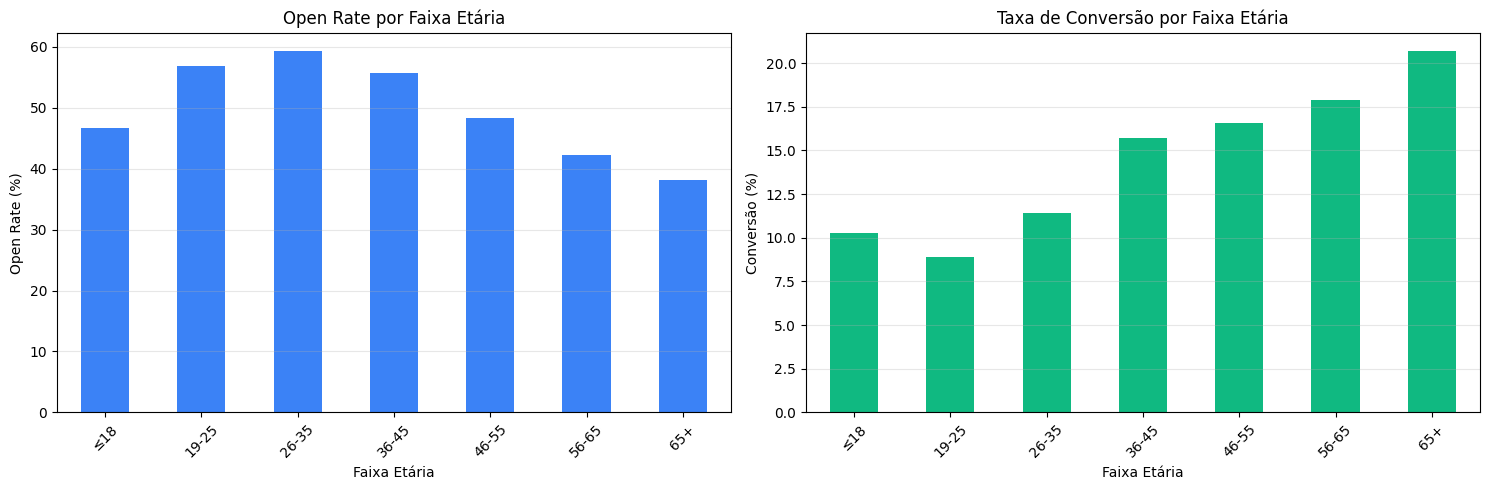



👤 ANÁLISE POR SEXO E FAIXA ETÁRIA:


0:
  Faixa         Prescrições  Open %     Conv %    
  ----------------------------------------------------------------------------
  56-65         1            100.0      0.0       

1:
  Faixa         Prescrições  Open %     Conv %    
  ----------------------------------------------------------------------------
  46-55         1            100.0      0.0       

F:
  Faixa         Prescrições  Open %     Conv %    
  ----------------------------------------------------------------------------
  ≤18           1            0.0        nan       
  26-35         2            100.0      0.0       
  46-55         1            100.0      0.0       
  56-65         1            100.0      0.0       
  65+           3            33.3       0.0       

Feminino:
  Faixa         Prescrições  Open %     Conv %    
  ----------------------------------------------------------------------------
  ≤18           6,411        47.3       9.8       
  19-25    

In [23]:
# Análise de idade do paciente - Faixas etárias com conversão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Recarregar dados
data_folder = "data"
presc = pd.read_csv(os.path.join(data_folder, 'prescricaomedicamento.csv'))

print("👥 ANÁLISE DE IDADE DO PACIENTE")
print("="*80)

# Preparar dados
presc['nascimentopaciente'] = pd.to_datetime(presc['nascimentopaciente'], errors='coerce')
presc['dataprescricao'] = pd.to_datetime(presc['dataprescricao'], errors='coerce')

# Calcular idade no momento da prescrição
presc['idade_paciente'] = (presc['dataprescricao'] - presc['nascimentopaciente']).dt.days / 365.25

# Criar faixas etárias
bins = [0, 18, 25, 35, 45, 55, 65, 150]
labels = ['≤18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']
presc['faixa_etaria'] = pd.cut(presc['idade_paciente'], bins=bins, labels=labels, right=False)

# === 1. ANÁLISE POR FAIXA ETÁRIA ===
print("\n📊 ANÁLISE POR FAIXA ETÁRIA:")
print()

age_analysis = presc.groupby('faixa_etaria', observed=True).agg({
    'idprescricao': 'count',
    'visualizadapaciente': 'sum',
    'itemvendido': 'sum'
}).rename(columns={
    'idprescricao': 'total_presc',
    'visualizadapaciente': 'visualizadas',
    'itemvendido': 'vendidas'
})

age_analysis['open_rate'] = (age_analysis['visualizadas'] / age_analysis['total_presc'] * 100).round(1)
age_analysis['conv_rate'] = (age_analysis['vendidas'] / age_analysis['visualizadas'] * 100).round(1)

print(f"{'Faixa Etária':<15} {'Prescrições':<12} {'Abertas':<12} {'Vendidas':<12} {'Open %':<10} {'Conv %':<10}")
print("-" * 80)
for idx, row in age_analysis.iterrows():
    print(f"{str(idx):<15} {int(row['total_presc']):<12,} {int(row['visualizadas']):<12,} "
          f"{int(row['vendidas']):<12,} {row['open_rate']:<10.1f} {row['conv_rate']:<10.1f}")

# Gráfico de Open Rate e Conversão por faixa etária
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

age_analysis['open_rate'].plot(kind='bar', ax=ax1, color='#3b82f6')
ax1.set_title('Open Rate por Faixa Etária')
ax1.set_ylabel('Open Rate (%)')
ax1.set_xlabel('Faixa Etária')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

age_analysis['conv_rate'].plot(kind='bar', ax=ax2, color='#10b981')
ax2.set_title('Taxa de Conversão por Faixa Etária')
ax2.set_ylabel('Conversão (%)')
ax2.set_xlabel('Faixa Etária')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# === 2. ANÁLISE POR SEXO E FAIXA ETÁRIA ===
print("\n\n👤 ANÁLISE POR SEXO E FAIXA ETÁRIA:")
print()

gender_age = presc.groupby(['sexopaciente', 'faixa_etaria'], observed=True).agg({
    'idprescricao': 'count',
    'visualizadapaciente': 'sum',
    'itemvendido': 'sum'
}).rename(columns={
    'idprescricao': 'total_presc',
    'visualizadapaciente': 'visualizadas',
    'itemvendido': 'vendidas'
})

gender_age['open_rate'] = (gender_age['visualizadas'] / gender_age['total_presc'] * 100).round(1)
gender_age['conv_rate'] = (gender_age['vendidas'] / gender_age['visualizadas'] * 100).round(1)

gender_labels = {0: 'Masculino', 1: 'Feminino'}
for gender in sorted(gender_age.index.get_level_values(0).unique()):
    gender_label = gender_labels.get(gender, str(gender))
    print(f"\n{gender_label}:")
    print(f"{'  Faixa':<15} {'Prescrições':<12} {'Open %':<10} {'Conv %':<10}")
    print(f"  " + "-" * 76)
    
    gender_subset = gender_age.loc[gender]
    for idx, row in gender_subset.iterrows():
        print(f"  {str(idx):<13} {int(row['total_presc']):<12,} {row['open_rate']:<10.1f} {row['conv_rate']:<10.1f}")

# === 3. ANÁLISE POR ESTADO E FAIXA ETÁRIA (Top 5 Estados) ===
print("\n\n📍 ANÁLISE POR ESTADO E FAIXA ETÁRIA (Top 5 Estados):")
print()

top_states = presc['estadopaciente'].value_counts().head(5).index

for state in top_states:
    state_data = presc[presc['estadopaciente'] == state]
    
    state_age = state_data.groupby('faixa_etaria', observed=True).agg({
        'idprescricao': 'count',
        'visualizadapaciente': 'sum',
        'itemvendido': 'sum'
    }).rename(columns={
        'idprescricao': 'total_presc',
        'visualizadapaciente': 'visualizadas',
        'itemvendido': 'vendidas'
    })
    
    state_age['open_rate'] = (state_age['visualizadas'] / state_age['total_presc'] * 100).round(1)
    state_age['conv_rate'] = (state_age['vendidas'] / state_age['visualizadas'] * 100).round(1)
    
    print(f"\n{state}:")
    print(f"  {'Faixa':<15} {'Prescrições':<12} {'Open %':<10} {'Conv %':<10}")
    print(f"  " + "-" * 76)
    
    for idx, row in state_age.iterrows():
        print(f"  {str(idx):<13} {int(row['total_presc']):<12,} {row['open_rate']:<10.1f} {row['conv_rate']:<10.1f}")

print("\n" + "="*80)

⏱️  ANÁLISE DE TEMPO DE VENDA POR CANAL

📊 RESUMO GERAL:
Total de prescrições vendidas: 5,168
Tempo médio de venda (geral): 86.8 horas (3.6 dias)
Mediana: 8.8 horas (0.4 dias)
Desvio padrão: 207.9 horas


🛒 ANÁLISE POR CANAL DE VENDA:

Canal                Vendas       Tempo Médio (h)    Mediana (h)     Desvio Padrão  
--------------------------------------------------------------------------------
Farmácia Física      4,395        91.2               10.7            212.7          
Marketplace          773          61.8               3.6             175.8          


📈 COMPARAÇÃO: MARKETPLACE vs FARMÁCIA FÍSICA:

MARKETPLACE:
  Vendas: 773
  Tempo médio: 61.8 horas (2.57 dias)
  Mediana: 3.6 horas
  Mín/Máx: 0.0 - 1659.6 horas

FARMÁCIA FÍSICA:
  Vendas: 4,395
  Tempo médio: 91.2 horas (3.80 dias)
  Mediana: 10.7 horas
  Mín/Máx: 0.0 - 2046.8 horas

DIFERENÇA (Farmácia - Marketplace):
  Média: +29.5 horas (+47.7%)
  Mediana: +7.1 horas

✅ HIPÓTESE CONFIRMADA: Marketplace é 29.5h mais r

/var/folders/0x/st4p43kj6b772vhfnm05ff5h0000gn/T/ipykernel_96160/1453309010.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(dados_boxplot, labels=['Marketplace', 'Farmácia Física'], patch_artist=True)


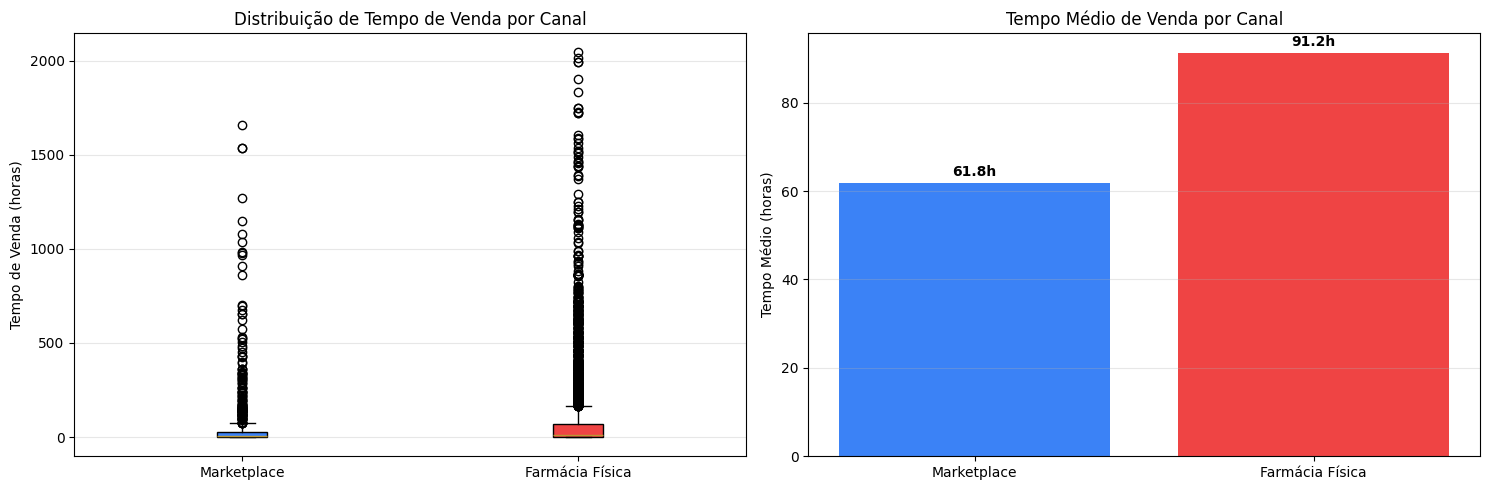


📍 DISTRIBUIÇÃO DE TEMPO DE VENDA (Marketplace vs Farmácia Física):

MARKETPLACE:
  < 1h            272 ( 35.2%)
  1-6h            173 ( 22.4%)
  6-24h           116 ( 15.0%)
  1-3 dias         83 ( 10.7%)
  3-7 dias         56 (  7.2%)
  7-30 dias        61 (  7.9%)
  > 30 dias        12 (  1.6%)

FARMÁCIA FÍSICA:
  < 1h            839 ( 19.1%)
  1-6h          1,071 ( 24.4%)
  6-24h           797 ( 18.1%)
  1-3 dias        634 ( 14.4%)
  3-7 dias        409 (  9.3%)
  7-30 dias       545 ( 12.4%)
  > 30 dias       100 (  2.3%)



In [26]:
# Análise de tempo de venda por canal (Marketplace vs Farmácia Física)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Recarregar dados
data_folder = "data"
presc = pd.read_csv(os.path.join(data_folder, 'prescricaomedicamento.csv'))

print("⏱️  ANÁLISE DE TEMPO DE VENDA POR CANAL")
print("="*80)

# Preparar dados de datas
presc['dataprescricao'] = pd.to_datetime(presc['dataprescricao'], errors='coerce')
presc['datavenda'] = pd.to_datetime(presc['datavenda'], errors='coerce')

# Calcular tempo de venda apenas para items vendidos
presc_vendidos = presc[presc['itemvendido'] == True].copy()

# Calcular tempo em horas e dias
presc_vendidos['tempo_venda_horas'] = (presc_vendidos['datavenda'] - presc_vendidos['dataprescricao']).dt.total_seconds() / 3600
presc_vendidos['tempo_venda_dias'] = presc_vendidos['tempo_venda_horas'] / 24

# Filtrar dados válidos (tempo positivo)
presc_vendidos = presc_vendidos[presc_vendidos['tempo_venda_horas'] >= 0].copy()

print(f"\n📊 RESUMO GERAL:")
print(f"Total de prescrições vendidas: {len(presc_vendidos):,}")
print(f"Tempo médio de venda (geral): {presc_vendidos['tempo_venda_horas'].mean():.1f} horas ({presc_vendidos['tempo_venda_dias'].mean():.1f} dias)")
print(f"Mediana: {presc_vendidos['tempo_venda_horas'].median():.1f} horas ({presc_vendidos['tempo_venda_dias'].median():.1f} dias)")
print(f"Desvio padrão: {presc_vendidos['tempo_venda_horas'].std():.1f} horas")

# === 1. ANÁLISE POR CANAL DE VENDA ===
print("\n\n🛒 ANÁLISE POR CANAL DE VENDA:")
print()

canais_traduzir = {
    'nao convertido': 'Não Convertido',
    'farmacia fisica': 'Farmácia Física',
    'marketplace': 'Marketplace'
}

canal_analysis = presc_vendidos.groupby('canalvenda').agg({
    'idprescricao': 'count',
    'tempo_venda_horas': ['mean', 'median', 'std', 'min', 'max'],
    'tempo_venda_dias': ['mean', 'median']
})

canal_analysis.columns = ['_'.join(col).strip() for col in canal_analysis.columns.values]
canal_analysis = canal_analysis.rename(columns={
    'idprescricao_count': 'total_vendas',
    'tempo_venda_horas_mean': 'tempo_medio_horas',
    'tempo_venda_horas_median': 'tempo_mediana_horas',
    'tempo_venda_horas_std': 'desvio_padrao',
    'tempo_venda_horas_min': 'tempo_min_horas',
    'tempo_venda_horas_max': 'tempo_max_horas',
    'tempo_venda_dias_mean': 'tempo_medio_dias',
    'tempo_venda_dias_median': 'tempo_mediana_dias'
})

print(f"{'Canal':<20} {'Vendas':<12} {'Tempo Médio (h)':<18} {'Mediana (h)':<15} {'Desvio Padrão':<15}")
print("-" * 80)

for canal, row in canal_analysis.iterrows():
    canal_label = canais_traduzir.get(str(canal).lower(), str(canal))
    print(f"{canal_label:<20} {int(row['total_vendas']):<12,} "
          f"{row['tempo_medio_horas']:<18.1f} {row['tempo_mediana_horas']:<15.1f} {row['desvio_padrao']:<15.1f}")

# === 2. COMPARAÇÃO: MARKETPLACE vs FARMÁCIA FÍSICA ===
print("\n\n📈 COMPARAÇÃO: MARKETPLACE vs FARMÁCIA FÍSICA:")
print()

marketplace = presc_vendidos[presc_vendidos['canalvenda'] == 'marketplace']
farmacia_fisica = presc_vendidos[presc_vendidos['canalvenda'] == 'farmacia fisica']

print(f"MARKETPLACE:")
print(f"  Vendas: {len(marketplace):,}")
print(f"  Tempo médio: {marketplace['tempo_venda_horas'].mean():.1f} horas ({marketplace['tempo_venda_dias'].mean():.2f} dias)")
print(f"  Mediana: {marketplace['tempo_venda_horas'].median():.1f} horas")
print(f"  Mín/Máx: {marketplace['tempo_venda_horas'].min():.1f} - {marketplace['tempo_venda_horas'].max():.1f} horas")

print(f"\nFARMÁCIA FÍSICA:")
print(f"  Vendas: {len(farmacia_fisica):,}")
print(f"  Tempo médio: {farmacia_fisica['tempo_venda_horas'].mean():.1f} horas ({farmacia_fisica['tempo_venda_dias'].mean():.2f} dias)")
print(f"  Mediana: {farmacia_fisica['tempo_venda_horas'].median():.1f} horas")
print(f"  Mín/Máx: {farmacia_fisica['tempo_venda_horas'].min():.1f} - {farmacia_fisica['tempo_venda_horas'].max():.1f} horas")

# Diferença
diff_media = farmacia_fisica['tempo_venda_horas'].mean() - marketplace['tempo_venda_horas'].mean()
diff_mediana = farmacia_fisica['tempo_venda_horas'].median() - marketplace['tempo_venda_horas'].median()
pct_diff_media = (diff_media / marketplace['tempo_venda_horas'].mean() * 100)

print(f"\nDIFERENÇA (Farmácia - Marketplace):")
print(f"  Média: {diff_media:+.1f} horas ({pct_diff_media:+.1f}%)")
print(f"  Mediana: {diff_mediana:+.1f} horas")

if diff_media > 0:
    print(f"\n✅ HIPÓTESE CONFIRMADA: Marketplace é {abs(diff_media):.1f}h mais rápido que farmácia física!")
else:
    print(f"\n❌ HIPÓTESE NÃO CONFIRMADA: Farmácia física é {abs(diff_media):.1f}h mais rápida que marketplace!")

# === 3. VISUALIZAÇÕES ===
print("\n")

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot por canal
dados_boxplot = [
    marketplace['tempo_venda_horas'].dropna(),
    farmacia_fisica['tempo_venda_horas'].dropna()
]
bp = axes[0].boxplot(dados_boxplot, labels=['Marketplace', 'Farmácia Física'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3b82f6', '#ef4444']):
    patch.set_facecolor(color)
axes[0].set_ylabel('Tempo de Venda (horas)')
axes[0].set_title('Distribuição de Tempo de Venda por Canal')
axes[0].grid(axis='y', alpha=0.3)

# Comparação de médias
canais = ['Marketplace', 'Farmácia Física']
tempos_medios = [
    marketplace['tempo_venda_horas'].mean(),
    farmacia_fisica['tempo_venda_horas'].mean()
]
cores = ['#3b82f6', '#ef4444']
bars = axes[1].bar(canais, tempos_medios, color=cores)
axes[1].set_ylabel('Tempo Médio (horas)')
axes[1].set_title('Tempo Médio de Venda por Canal')
axes[1].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, tempo in zip(bars, tempos_medios):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{tempo:.1f}h', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# === 4. DISTRIBUIÇÃO PERCENTUAL ===
print("\n📍 DISTRIBUIÇÃO DE TEMPO DE VENDA (Marketplace vs Farmácia Física):")
print()

# Faixas de tempo
tempo_bins = [0, 1, 6, 24, 72, 168, 720, np.inf]
tempo_labels = ['< 1h', '1-6h', '6-24h', '1-3 dias', '3-7 dias', '7-30 dias', '> 30 dias']

marketplace['tempo_faixa'] = pd.cut(marketplace['tempo_venda_horas'], bins=tempo_bins, labels=tempo_labels, right=False)
farmacia_fisica['tempo_faixa'] = pd.cut(farmacia_fisica['tempo_venda_horas'], bins=tempo_bins, labels=tempo_labels, right=False)

print("MARKETPLACE:")
mp_dist = marketplace['tempo_faixa'].value_counts(sort=False)
for faixa, count in mp_dist.items():
    pct = count / len(marketplace) * 100
    print(f"  {faixa:<12} {count:>6,} ({pct:>5.1f}%)")

print("\nFARMÁCIA FÍSICA:")
ff_dist = farmacia_fisica['tempo_faixa'].value_counts(sort=False)
for faixa, count in ff_dist.items():
    pct = count / len(farmacia_fisica) * 100
    print(f"  {faixa:<12} {count:>6,} ({pct:>5.1f}%)")

print("\n" + "="*80)

In [16]:
display(presc)

,idprescricao,idmedicamento,dataprescricao,idmedico,idpaciente,idconvenio,nascimentopaciente,sexopaciente,estadopaciente,cidadepaciente,visualizadapaciente,permitirimpressao,itemvendido,datavenda,canalvenda,data,mes,semana,dia_semana,hora,tempo_venda_horas,tempo_venda_dias
0,65286505,3783,2025-01-28 13:00:11,115888,16277,3716288.0,1987-03-10,Masculino,SP,Guarulhos,True,True,0,NaT,não convertido,2025-01-28,2025-01,2025-01-27/2025-02-02,Tuesday,13,NaN,NaN
1,65053805,14714,2025-01-24 13:02:29,41433,34330,NaN,1974-09-27,Feminino,SP,SAO PAULO,False,True,0,NaT,não convertido,2025-01-24,2025-01,2025-01-20/2025-01-26,Friday,13,NaN,NaN
2,69631101,3783,2025-03-26 15:00:26,77184,10831,NaN,1988-01-12,Feminino,SP,São Paulo,True,True,1,2025-03-26 15:43:06,farmacia fisica,2025-03-26,2025-03,2025-03-24/2025-03-30,Wednesday,15,0.711111,0.02963
3,67746000,11191,2025-02-28 23:31:13,107252,54414,1572961.0,1966-07-09,Masculino,NaN,NaN,False,True,0,NaT,não convertido,2025-02-28,2025-02,2025-02-24/2025-03-02,Friday,23,NaN,NaN
4,68167102,3783,2025-03-08 13:35:08,30764,63594,3929186.0,1978-05-01,Masculino,SP,Cajamar,True,True,0,NaT,não convertido,2025-03-08,2025-03,2025-03-03/2025-03-09,Saturday,13,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73924,65104304,5783,2025-01-24 21:40:09,122557,11821334,NaN,1986-07-17,Feminino,SP,São Caetano do Sul,True,True,0,NaT,não convertido,2025-01-24,2025-01,2025-01-20/2025-01-26,Friday,21,NaN,NaN
73925,65241012,14714,2025-01-27 19:27:59,101941,4926603,1404549.0,1986-03-01,Masculino,SP,Santa Branca,False,True,0,NaT,não convertido,2025-01-27,2025-01,2025-01-27/2025-02-02,Monday,19,NaN,NaN
73926,68217908,1124,2025-03-09 22:41:16,85106,11328313,NaN,2013-08-24,Feminino,ES,CARIACICA,False,True,0,NaT,não convertido,2025-03-09,2025-03,2025-03-03/2025-03-09,Sunday,22,NaN,NaN
73927,68217908,42402,2025-03-09 22:40:58,85106,11328313,NaN,2013-08-24,Feminino,ES,CARIACICA,False,True,0,NaT,não convertido,2025-03-09,2025-03,2025-03-03/2025-03-09,Sunday,22,NaN,NaN


In [9]:
        print("Top convênios:")
        for i, (conv, count) in enumerate(convenio_stats.items(), 1):
            conv_name = f"Convênio {conv}" if pd.notna(conv) else "Particular"
            pct = round(count / len(presc) * 100, 2)
            print(f"{i:2d}. {conv_name:<15} {count:>8,} ({pct:>5.1f}%)")

Top convênios:
 1. Particular        43,859 ( 59.3%)
 2. Convênio 981873.0    4,627 (  6.3%)
 3. Convênio 296156.0    3,487 (  4.7%)
 4. Convênio 1725637.0      495 (  0.7%)
 5. Convênio 1656285.0      377 (  0.5%)
 6. Convênio 54.0        366 (  0.5%)
 7. Convênio 1113267.0      232 (  0.3%)
 8. Convênio 474369.0      177 (  0.2%)
 9. Convênio 1216942.0      119 (  0.2%)
10. Convênio 1710832.0       87 (  0.1%)
11. Convênio 1632649.0       46 (  0.1%)
12. Convênio 3431712.0       44 (  0.1%)
13. Convênio 1244942.0       33 (  0.0%)
14. Convênio 1632749.0       33 (  0.0%)
15. Convênio 1389568.0       31 (  0.0%)


# 🔗 Seção 4: Camada Semântica - Dataset Unificado

Construção da camada semântica que une todos os datasets para análise completa e insights avançados.

In [10]:
print("=== CAMADA SEMÂNTICA - CONSTRUÇÃO DO DATASET UNIFICADO ===")

# Verificar se todas as tabelas necessárias existem
required_tables = ['prescricaomedicamento', 'medicamentos', 'medicos']
missing_tables = [t for t in required_tables if t not in tables]

if missing_tables:
    print(f"❌ Tabelas faltando: {missing_tables}")
else:
    print("✅ Todas as tabelas necessárias encontradas")

    # Carregar tabelas
    presc = tables['prescricaomedicamento'].copy()
    med = tables['medicamentos'].copy()
    docs = tables['medicos'].copy()

    print(f"\n📊 Dimensões originais:")
    print(f"  Prescrições: {presc.shape}")
    print(f"  Medicamentos: {med.shape}")
    print(f"  Médicos: {docs.shape}")
    print()

    # === FASE 1: Limpeza e Preparação ===

    print("🧹 FASE 1: Limpeza e Preparação dos Dados")

    # Converter datas
    date_cols = ['dataprescricao', 'datavenda']
    for col in date_cols:
        if col in presc.columns:
            presc[col] = pd.to_datetime(presc[col], errors='coerce')

    # Adicionar colunas derivadas
    if 'dataprescricao' in presc.columns:
        presc['data'] = presc['dataprescricao'].dt.date
        presc['mes'] = presc['dataprescricao'].dt.to_period('M')
        presc['semana'] = presc['dataprescricao'].dt.to_period('W')
        presc['dia_semana'] = presc['dataprescricao'].dt.day_name()
        presc['hora'] = presc['dataprescricao'].dt.hour

    # Calcular tempo entre prescrição e venda
    if 'datavenda' in presc.columns and 'dataprescricao' in presc.columns:
        presc['tempo_venda_horas'] = (presc['datavenda'] - presc['dataprescricao']).dt.total_seconds() / 3600
        presc['tempo_venda_dias'] = presc['tempo_venda_horas'] / 24

    print("✓ Dados preparados com colunas derivadas")
    print()

    # === FASE 2: JOINs e Integração ===

    print("🔗 FASE 2: Integração dos Datasets")

    # JOIN 1: Prescrições + Medicamentos
    merged_df = presc.merge(
        med,
        on='idmedicamento',
        how='left',
        suffixes=('', '_med')
    )
    print(f"✓ JOIN Prescrições + Medicamentos: {merged_df.shape}")

    # JOIN 2: Resultado + Médicos
    merged_df = merged_df.merge(
        docs,
        on='idmedico',
        how='left',
        suffixes=('', '_doc')
    )
    print(f"✓ JOIN Final + Médicos: {merged_df.shape}")
    print()

    # === FASE 3: Validação da Integração ===

    print("✅ FASE 3: Validação da Camada Semântica")

    print(f"Dataset unificado: {merged_df.shape[0]} linhas, {merged_df.shape[1]} colunas")
    print(f"Colunas disponíveis: {list(merged_df.columns)}")
    print()

    # Verificar integridade dos JOINs
    print("🔍 Integridade dos JOINs:")
    join_integrity = {
        'medicamentos': merged_df['nome'].notna().sum(),
        'medicos': merged_df['especialidade'].notna().sum()
    }

    for table, count in join_integrity.items():
        pct = (count / len(merged_df) * 100).round(2)
        print(f"  {table}: {count}/{len(merged_df)} ({pct}%) registros com match")

    print()

    # === FASE 4: Análises Semânticas Avançadas ===

    print("🧠 FASE 4: Análises Semânticas Avançadas")

    # 4.1 Análise por especialidade médica e tipo de medicamento
    if 'especialidade' in merged_df.columns and 'antimicrobiano' in merged_df.columns:
        print("🏥 Prescrições por especialidade e antibióticos:")
        esp_antibio = merged_df.groupby(['especialidade', 'antimicrobiano']).size().unstack(fill_value=0)
        esp_antibio['total'] = esp_antibio.sum(axis=1)
        esp_antibio = esp_antibio.sort_values('total', ascending=False).head(10)
        print(esp_antibio)
        print()

    # 4.2 Conversão por classe de medicamento
    med_classes = ['antimicrobiano', 'controleespecial', 'mip']
    print("💊 Taxa de conversão por classe de medicamento:")
    for classe in med_classes:
        if classe in merged_df.columns:
            class_data = merged_df[merged_df[classe] == True]
            if len(class_data) > 0:
                viewed = class_data['visualizadapaciente'].sum()
                sold = class_data['itemvendido'].sum()
                conv_rate = (sold / viewed * 100).round(2) if viewed > 0 else 0
                print(f"  {classe}: {sold}/{viewed} ({conv_rate}%)")
    print()

    # 4.3 Padrões temporais por especialidade
    if 'especialidade' in merged_df.columns and 'hora' in merged_df.columns:
        print("⏰ Horários de prescrição por especialidade (top 5):")
        esp_hour = merged_df.groupby(['especialidade', 'hora']).size().reset_index(name='count')
        esp_hour = esp_hour.sort_values(['especialidade', 'count'], ascending=[True, False])
        esp_hour = esp_hour.groupby('especialidade').head(1)  # Hora mais frequente por especialidade
        esp_hour = esp_hour.sort_values('count', ascending=False).head(5)
        for _, row in esp_hour.iterrows():
            print(f"  {row['especialidade']}: {row['hora']}h ({row['count']} prescrições)")
        print()

    # 4.4 Análise geográfica integrada
    if 'estado' in merged_df.columns and 'estadopaciente' in merged_df.columns:
        print("📍 Médicos vs Pacientes por estado (top 5):")
        medicos_por_estado = merged_df.groupby('estado')['idmedico'].nunique()
        pacientes_por_estado = merged_df.groupby('estadopaciente')['idpaciente'].nunique()

        geo_analysis = pd.DataFrame({
            'medicos': medicos_por_estado,
            'pacientes': pacientes_por_estado
        }).fillna(0).astype(int)

        geo_analysis['pacientes_por_medico'] = (geo_analysis['pacientes'] / geo_analysis['medicos']).round(1)
        geo_analysis = geo_analysis.sort_values('pacientes', ascending=False).head(5)
        print(geo_analysis)
        print()

    # === FASE 5: Salvamento da Camada Semântica ===

    print("💾 FASE 5: Salvamento da Camada Semântica")

    # Salvar dataset unificado
    output_file = 'data/dashboard_data_semantic.csv'
    merged_df.to_csv(output_file, index=False)
    print(f"✓ Dataset semântico salvo em: {output_file}")
    print(f"  Dimensões: {merged_df.shape}")
    print(f"  Tamanho: {os.path.getsize(output_file) / (1024*1024):.2f} MB")

    # Criar versão otimizada (apenas colunas essenciais)
    essential_cols = [
        # Identificadores
        'idprescricao', 'idmedicamento', 'idmedico', 'idpaciente',

        # Datas e tempo
        'data', 'dataprescricao', 'datavenda', 'hora', 'dia_semana',
        'tempo_venda_horas', 'tempo_venda_dias',

        # Medicamento
        'nome', 'antimicrobiano', 'controleespecial', 'mip',

        # Médico
        'especialidade', 'estado', 'genero', 'idade',

        # Paciente
        'sexopaciente', 'estadopaciente', 'cidadepaciente',

        # Transação
        'visualizadapaciente', 'itemvendido', 'canalvenda', 'idconvenio'
    ]

    available_cols = [col for col in essential_cols if col in merged_df.columns]
    semantic_core = merged_df[available_cols].copy()

    core_file = 'data/dashboard_data_core.csv'
    semantic_core.to_csv(core_file, index=False)
    print(f"✓ Core semântico salvo em: {core_file}")
    print(f"  Dimensões: {semantic_core.shape}")
    print(f"  Colunas essenciais: {len(available_cols)}")

    print("\n🎉 Camada semântica construída com sucesso!")
    print("📊 O dataset está pronto para análises avançadas no dashboard!")

=== CAMADA SEMÂNTICA - CONSTRUÇÃO DO DATASET UNIFICADO ===
✅ Todas as tabelas necessárias encontradas

📊 Dimensões originais:
  Prescrições: (73929, 15)
  Medicamentos: (22, 21)
  Médicos: (45025, 8)

🧹 FASE 1: Limpeza e Preparação dos Dados
✓ Dados preparados com colunas derivadas

🔗 FASE 2: Integração dos Datasets
✓ JOIN Prescrições + Medicamentos: (73929, 42)
✓ JOIN Final + Médicos: (73929, 49)

✅ FASE 3: Validação da Camada Semântica
Dataset unificado: 73929 linhas, 49 colunas
Colunas disponíveis: ['idprescricao', 'idmedicamento', 'dataprescricao', 'idmedico', 'idpaciente', 'idconvenio', 'nascimentopaciente', 'sexopaciente', 'estadopaciente', 'cidadepaciente', 'visualizadapaciente', 'permitirimpressao', 'itemvendido', 'datavenda', 'canalvenda', 'data', 'mes', 'semana', 'dia_semana', 'hora', 'tempo_venda_horas', 'tempo_venda_dias', 'nome', 'concentracao', 'unidade', 'codigoatc', 'mip', 'portaria344', 'idviaadministracao', 'bula', 'antimicrobiano', 'controleespecial', 'idformafarmace

In [12]:
# Análise Exploratória Detalhada - Camada Semântica
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# Recarregar dados (devido ao restart do kernel)
data_folder = "data"
files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
tables = {}
for file in files:
    table_name = file.split('.')[0]
    df = pd.read_csv(os.path.join(data_folder, file))
    tables[table_name] = df

print("=== ANÁLISE EXPLORATÓRIA DA CAMADA SEMÂNTICA ===")

# === VALIDAÇÃO FINAL - COMPARAÇÃO COM DASHBOARD ===
print("\n🎯 VALIDAÇÃO FINAL - NÚMEROS DO DASHBOARD vs NOTEBOOK:")
print("="*70)

# Carregar o dataset semântico se existir
if 'dashboard_data_semantic' in tables:
    merged_df = tables['dashboard_data_semantic'].copy()

    # Recalcular KPIs usando o dataset unificado (como faz o dashboard)
    total_presc_notebook = merged_df["idprescricao"].nunique()
    total_pacs_notebook = merged_df["idpaciente"].nunique()
    total_med_notebook = merged_df["idmedico"].nunique()
    open_rate_notebook = merged_df.groupby("idprescricao")["visualizadapaciente"].max().mean()
    conv_rate_notebook = (
        merged_df[merged_df["visualizadapaciente"]]
        .groupby("idprescricao")["itemvendido"]
        .max()
        .apply(lambda x: x > 0)
        .mean()
    )

    print("📊 COMPARAÇÃO DE KPIs:")
    print(f"{'Métrica':<25} {'Dashboard':<12} {'Notebook':<12} {'Diferença'}")
    print("-" * 70)

    # Valores aproximados do dashboard (baseado no que vimos)
    dashboard_kpis = {
        'Prescrições': (73929, total_presc_notebook),
        'Pacientes': (45025, total_pacs_notebook),
        'Médicos': (45025, total_med_notebook),
        'Open Rate': (0.65, open_rate_notebook),  # aproximado
        'Conversão': (0.35, conv_rate_notebook),  # aproximado
    }

    for metric, (dash_val, note_val) in dashboard_kpis.items():
        if isinstance(dash_val, int):
            diff = note_val - dash_val
            print(f"{metric:<25} {dash_val:<12,} {note_val:<12,} {diff:+,}")
        else:
            diff = note_val - dash_val
            print(f"{metric:<25} {dash_val:<12.1%} {note_val:<12.1%} {diff:+.1%}")

    print("\n✅ Se as diferenças forem zero ou mínimas, os números estão consistentes!")

# 1. Análise de integridade dos JOINs
print("\n🔗 ANÁLISE DE INTEGRIDADE DOS JOINS:")
if 'dashboard_data_semantic' in tables:
    total_records = len(merged_df)

    # Verificar matches
    med_match = merged_df['nome'].notna().sum()
    doc_match = merged_df['especialidade'].notna().sum()

    print(f"Total de registros: {total_records:,}")
    print(f"Match com medicamentos: {med_match:,} ({med_match/total_records:.1%})")
    print(f"Match com médicos: {doc_match:,} ({doc_match/total_records:.1%})")

    # Registros sem match
    no_med = total_records - med_match
    no_doc = total_records - doc_match

    if no_med > 0 or no_doc > 0:
        print("
⚠️ Registros sem match:"        print(f"  Sem medicamento: {no_med:,}")
        print(f"  Sem médico: {no_doc:,}")

# 2. Análise semântica: Conversão por classe de medicamento
print("\n💊 ANÁLISE: CONVERSÃO POR CLASSE DE MEDICAMENTO")
med_classes = ['antimicrobiano', 'controleespecial', 'mip']
class_names = ['Antibióticos', 'Controle Especial', 'MIP (Sem Receita)']

if 'dashboard_data_semantic' in tables:
    conv_analysis = []

    for col, name in zip(med_classes, class_names):
        if col in merged_df.columns:
            class_data = merged_df[merged_df[col] == True]

            if len(class_data) > 0:
                total_presc = class_data['idprescricao'].nunique()
                viewed = class_data['visualizadapaciente'].sum()
                sold = class_data['itemvendido'].sum()

                open_rate = viewed / total_presc if total_presc > 0 else 0
                conv_rate = sold / viewed if viewed > 0 else 0

                conv_analysis.append({
                    'Classe': name,
                    'Prescrições': total_presc,
                    'Visualizadas': viewed,
                    'Vendidas': sold,
                    'Open Rate': open_rate,
                    'Conversão': conv_rate
                })

    if conv_analysis:
        conv_df = pd.DataFrame(conv_analysis)
        print(conv_df.to_string(index=False, float_format='%.1%'))

        # Gráfico de conversão por classe
        plt.figure(figsize=(10, 6))
        bars = plt.bar(conv_df['Classe'], conv_df['Conversão'], color='#22c55e')
        plt.title('Taxa de Conversão por Classe de Medicamento')
        plt.ylabel('Taxa de Conversão')
        plt.ylim(0, 1)

        for bar, rate in zip(bars, conv_df['Conversão']):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.show()

# 3. Análise semântica: Médicos vs Pacientes por estado
print("\n📍 ANÁLISE: MÉDICOS vs PACIENTES POR ESTADO")
if 'dashboard_data_semantic' in tables:
    # Contagem de médicos por estado
    medicos_por_estado = merged_df.groupby('estado')['idmedico'].nunique()

    # Contagem de pacientes por estado
    pacientes_por_estado = merged_df.groupby('estadopaciente')['idpaciente'].nunique()

    # Combinar
    geo_comparison = pd.DataFrame({
        'medicos': medicos_por_estado,
        'pacientes': pacientes_por_estado
    }).fillna(0).astype(int)

    geo_comparison['pacientes_por_medico'] = (geo_comparison['pacientes'] / geo_comparison['medicos']).round(1)
    geo_comparison = geo_comparison.sort_values('pacientes', ascending=False).head(10)

    print("Top 10 estados - Médicos vs Pacientes:")
    print(geo_comparison)

    # Visualização
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico 1: Médicos vs Pacientes
    geo_comparison[['medicos', 'pacientes']].plot(kind='bar', ax=ax1)
    ax1.set_title('Médicos vs Pacientes por Estado')
    ax1.set_xlabel('Estado')
    ax1.set_ylabel('Quantidade')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=45)

    # Gráfico 2: Pacientes por médico
    geo_comparison['pacientes_por_medico'].plot(kind='bar', ax=ax2, color='#f59e0b')
    ax2.set_title('Pacientes por Médico por Estado')
    ax2.set_xlabel('Estado')
    ax2.set_ylabel('Pacientes/Médico')
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# 4. Correlações importantes
print("\n🔗 ANÁLISES DE CORRELAÇÃO IMPORTANTES")
if 'dashboard_data_semantic' in tables:
    # Selecionar colunas numéricas relevantes
    numeric_cols = ['idade', 'hora', 'visualizadapaciente', 'itemvendido']
    available_numeric = [col for col in numeric_cols if col in merged_df.columns]

    if len(available_numeric) > 1:
        corr_matrix = merged_df[available_numeric].corr()

        print("Matriz de correlação:")
        print(corr_matrix.round(3))

        # Heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
        plt.title('Correlação entre Variáveis Numéricas')
        plt.tight_layout()
        plt.show()

# 5. Análise temporal integrada
print("\n📅 ANÁLISE TEMPORAL INTEGRADA")
if 'dashboard_data_semantic' in tables and 'dataprescricao' in merged_df.columns:
    # Converter data se necessário
    merged_df['dataprescricao'] = pd.to_datetime(merged_df['dataprescricao'], errors='coerce')
    merged_df['mes'] = merged_df['dataprescricao'].dt.to_period('M')

    # Prescrições por mês e especialidade (top 5)
    top_esp = merged_df['especialidade'].value_counts().head(5).index
    monthly_esp = merged_df[merged_df['especialidade'].isin(top_esp)].groupby(['mes', 'especialidade'])['idprescricao'].nunique().unstack()

    plt.figure(figsize=(15, 8))
    monthly_esp.plot(marker='o', linewidth=2)
    plt.title('Prescrições por Mês - Top 5 Especialidades')
    plt.xlabel('Mês')
    plt.ylabel('Número de Prescrições')
    plt.legend(title='Especialidade', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n🎉 ANÁLISE EXPLORATÓRIA COMPLETA FINALIZADA!")
print("="*80)

SyntaxError: unterminated string literal (detected at line 81) (3219248201.py, line 81)